<!--- Project Title --->
<span class="dates">Kelompok 4 | UTS Praktikum Pembelajaran Mesin</span><br>
<span class="title-normal">Dataset </span>
<span class="title-highlight">Bank Customer Churn</span><br>
<hr>


# <div class="header1">Pembagian Tugas</div>
<div class="explain-box">
    <table>
      <thead>
        <tr>
          <th>No</th>
          <th>Nama</th>
          <th>NPM</th>
          <th>Tugas</th>
        </tr>
      </thead>
      <tbody>
        <tr>
          <td>1</td>
          <td>Nurul Uzratun Nashriyyah</td>
          <td>2208107010030</td>
          <td>Eksplorasi Data (EDA) dan Visualisasi</td>
        </tr>
        <tr>
          <td>2</td>
          <td>Zahra Zafira</td>
          <td>2208107010040</td>
          <td>Preprocessing Data dan Pemilihan Fitur</td>
        </tr>
        <tr>
          <td>3</td>
          <td>Alhusna Hanifah</td>
          <td>2208107010060</td>
          <td>Implementasi Model, Evaluasi dan Analisis Hasil</td>
        </tr>
        <tr>
          <td>4</td>
          <td>Fadli Ahmad Yazid</td>
          <td>2208107010032</td>
          <td>Analisis Regresi</td>
        </tr>
        <tr>
          <td>5</td>
          <td>Rizky Yusmansyah</td>
          <td>2208107010024</td>
          <td>Analisis Regresi</td>
        </tr>
      </tbody>
    </table>
</div>

# Bank Customer Churn
---

## 📊 Informasi Dataset: *Banking Customer Churn Prediction Dataset*

### 📁 Sumber Dataset:
Dataset ini berasal dari repositori terbuka dan digunakan secara luas untuk keperluan analisis data dan pembelajaran mesin, khususnya dalam memprediksi *customer churn* (pelanggan yang berhenti menggunakan layanan) pada sektor perbankan. Dataset ini tersedia di berbagai platform seperti Kaggle.

### 🧾 Deskripsi Umum:
Dataset ini berisi informasi tentang nasabah bank, termasuk status apakah nasabah tersebut telah berhenti menjadi pelanggan (*Exited*) atau tidak. Dataset ini cocok digunakan untuk:
- **Analisis eksploratif (EDA)**: Menggali faktor-faktor yang memengaruhi keputusan nasabah untuk berhenti menggunakan layanan bank.
- **Pemodelan prediktif (Machine Learning)**: Membangun model untuk memprediksi nasabah yang berisiko keluar dari bank berdasarkan fitur-fitur yang tersedia.

---

### 🔍 Penjelasan Setiap Fitur:

| Fitur | Penjelasan |
|-------|------------|
| `RowNumber` | Nomor urut dari setiap baris dalam dataset (sebagai identifikasi urutan data). |
| `CustomerId` | ID unik yang diberikan untuk setiap nasabah bank. |
| `Surname` | Nama belakang nasabah. |
| `CreditScore` | Skor kredit nasabah, menunjukkan kelayakan finansial mereka. |
| `Geography` | Lokasi geografis nasabah (misalnya negara: Prancis, Spanyol, Jerman). |
| `Gender` | Jenis kelamin nasabah (Laki-laki/Perempuan). |
| `Age` | Usia nasabah. |
| `Tenure` | Lama waktu (dalam tahun) nasabah menjadi pelanggan di bank. |
| `Balance` | Saldo yang dimiliki nasabah dalam rekeningnya. |
| `NumOfProducts` | Jumlah produk perbankan yang dimiliki nasabah (misalnya: pinjaman, tabungan, kartu kredit). |
| `HasCrCard` | Apakah nasabah memiliki kartu kredit atau tidak (1 = ya, 0 = tidak). |
| `IsActiveMember` | Apakah nasabah merupakan anggota aktif atau tidak (1 = aktif, 0 = tidak aktif). |
| `EstimatedSalary` | Perkiraan gaji atau penghasilan nasabah. |
| `Exited` | Target variabel (label), menunjukkan apakah nasabah keluar dari bank (1 = keluar, 0 = tetap). |

---

### 📦 Ukuran Dataset:
Ukuran dataset standar ini umumnya terdiri dari:
- **Jumlah Baris**: 10.000 data nasabah
- **Jumlah Kolom**: 14 fitur (termasuk target `Exited`)

## 1. 🧰 Import Library

Mengimpor berbagai library yang diperlukan dalam proses pembuatan model machine learning. Fungsi utamanya meliputi:

- **Pemrosesan teks** menggunakan Sentence Transformers.
- **Pembagian dataset**, **pencarian hyperparameter terbaik**, dan **pra-pemrosesan data**.
- **Pembuatan model klasifikasi** seperti Logistic Regression, Random Forest, dan XGBoost.
- **Penanganan data tidak seimbang** menggunakan SMOTE.
- **Evaluasi performa model** melalui metrik klasifikasi dan confusion matrix.
- **Visualisasi data dan hasil model** menggunakan Matplotlib dan Seaborn.
- **Normalisasi fitur** untuk meningkatkan performa model.

In [ ]:
%pip install seaborn

                                              0.0/294.9 kB ? eta -:--:--
     --------                                61.4/294.9 kB 1.1 MB/s eta 0:00:01
     -----------------------                184.3/294.9 kB 1.9 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 2.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 2. 📥 Load Dataset

Membaca dataset **Churn Modelling** dari file CSV menggunakan `pandas`. Dataset ini akan digunakan sebagai data utama untuk analisis dan pemodelan.


In [ ]:
# Ganti path jika diperlukan
df = pd.read_csv('/content/Churn_Modelling.csv')
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Exploratory Data Analysis (EDA)

Analisis ini bertujuan untuk memahami pola dan insight dari data churn nasabah bank sebelum melanjutkan ke tahap pemodelan. Dengan eksplorasi data, kita bisa mengetahui fitur mana yang relevan, apakah datanya seimbang, dan pola-pola awal yang mungkin menunjukkan faktor-faktor penyebab churn.


In [ ]:
# Informasi umum
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
#cek missing value
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### 💡 Catatan Penting
- Kolom bertipe `object` (`Surname`, `Geography`, `Gender`) adalah data kategori dan perlu di-*encode* sebelum digunakan dalam model.
- Kolom seperti `RowNumber`, `CustomerId`, dan `Surname` biasanya tidak digunakan untuk prediksi karena tidak memiliki pengaruh terhadap target `Exited`.
- Tidak ada missing value di dataset — semua kolom memiliki 10.000 nilai (✅ bersih), yang membuatnya siap untuk tahap preprocessing lebih lanjut.

In [ ]:
# Statistik deskriptif
df.describe()


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
# cek data duplikat
df.duplicated().sum()

np.int64(0)

### 🧠 Insight Awal
- Sekitar **20.37%** nasabah melakukan churn. Ini menunjukkan bahwa data sedikit **imbalanced**.
- Data bersih tanpa duplikasi dan tidak memiliki outlier ekstrem, sehingga cukup siap untuk tahap berikutnya (preprocessing & modeling).

### Univariate Analysis
#### 🎯 Distribusi Target `Exited`

In [ ]:
df['Exited'].unique()

array([1, 0])

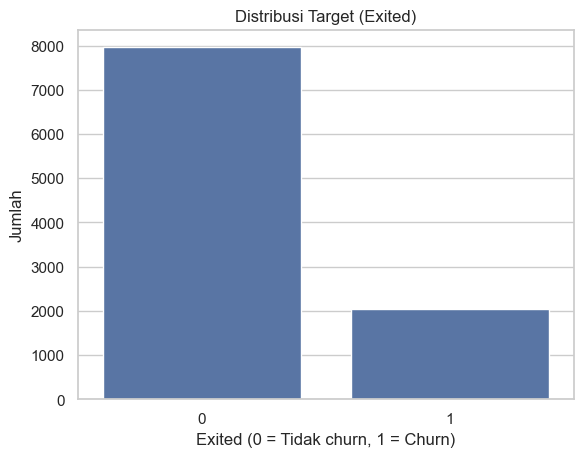

In [ ]:
# Distribusi target
sns.countplot(data=df, x='Exited')
plt.title("Distribusi Target (Exited)")
plt.xlabel("Exited (0 = Tidak churn, 1 = Churn)")
plt.ylabel("Jumlah")
plt.show()


Visualisasi `countplot` pada kolom `Exited` memberikan gambaran:
- Mayoritas nasabah **tidak churn** (Exited = 0)
- Sekitar 20% dari total nasabah melakukan **churn** (Exited = 1)

Artinya, data ini sedikit **imbalanced**, yang bisa menjadi pertimbangan saat membuat model klasifikasi nantinya.


#### 🔢 Kolom Numerik


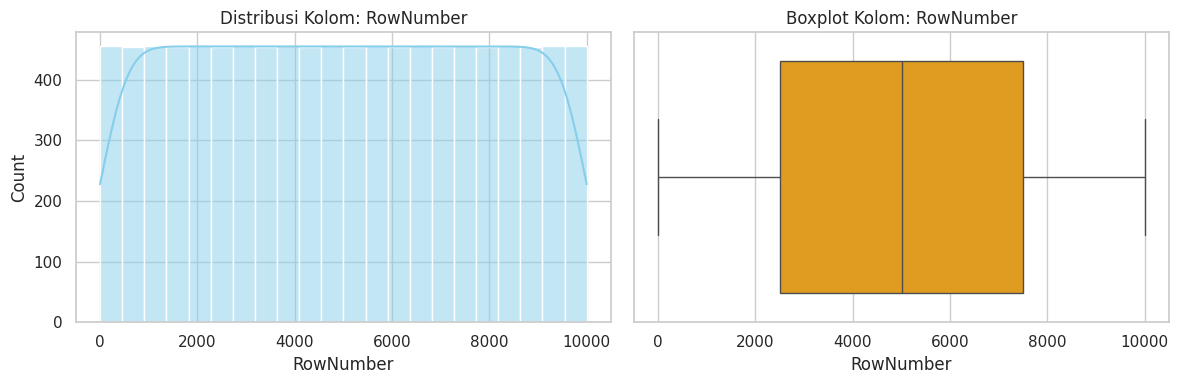

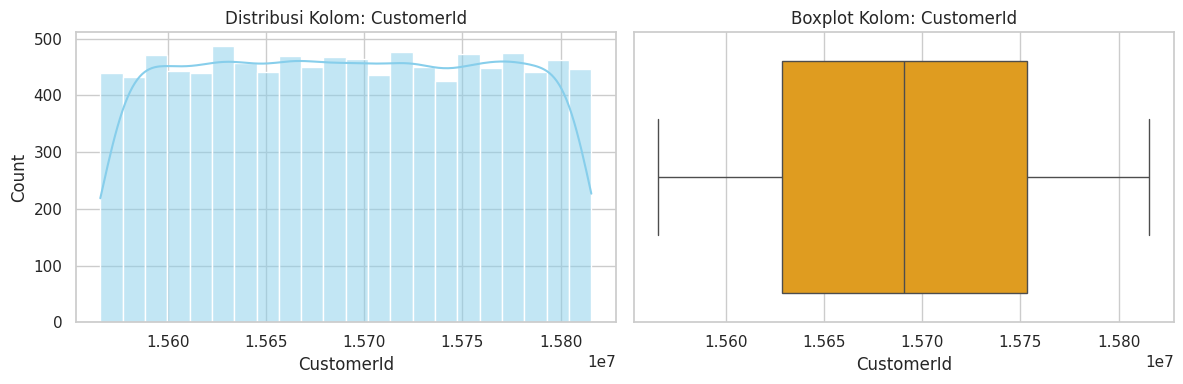

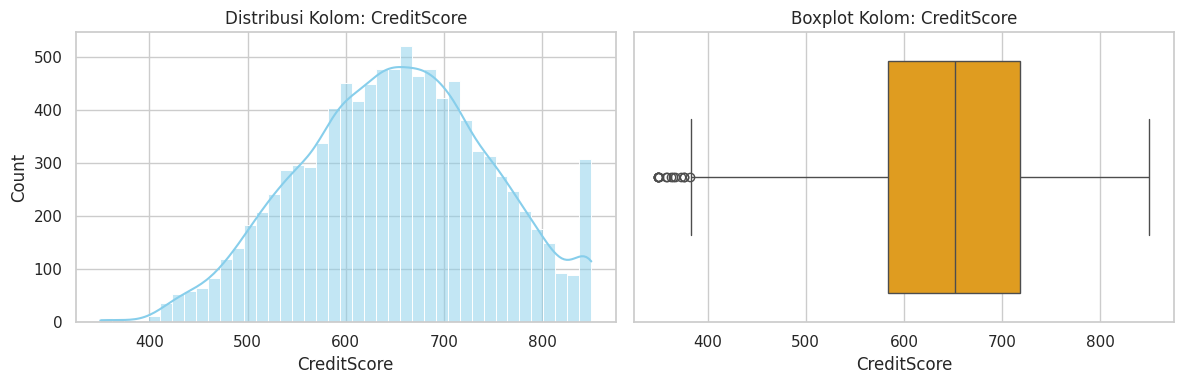

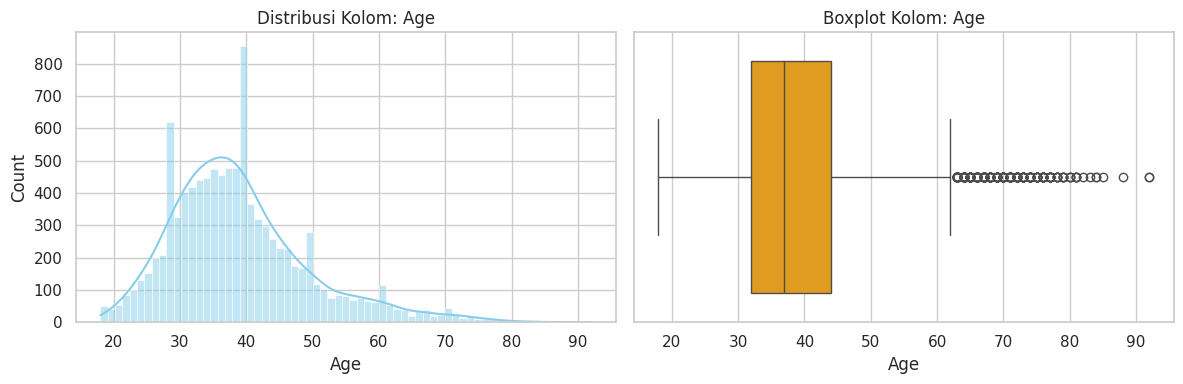

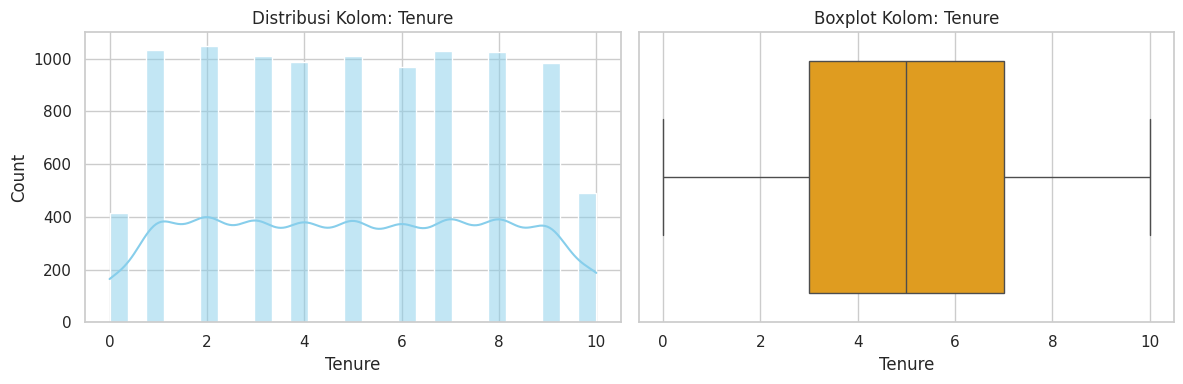

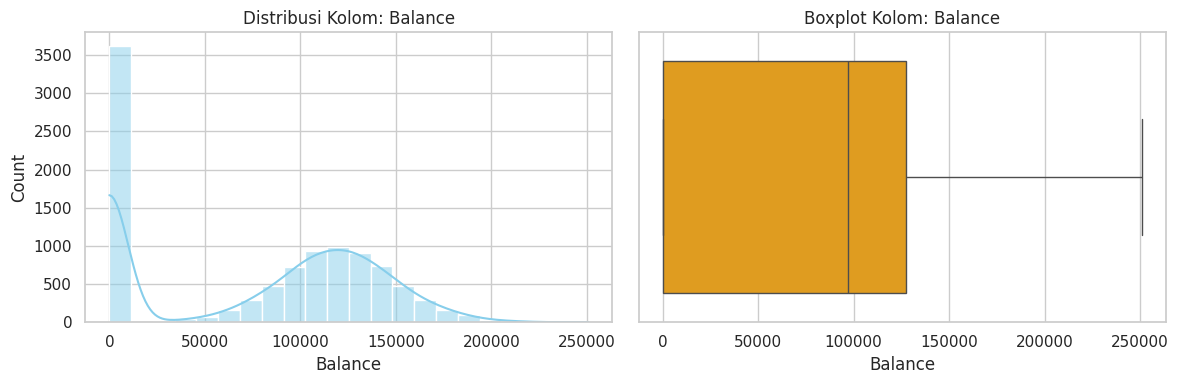

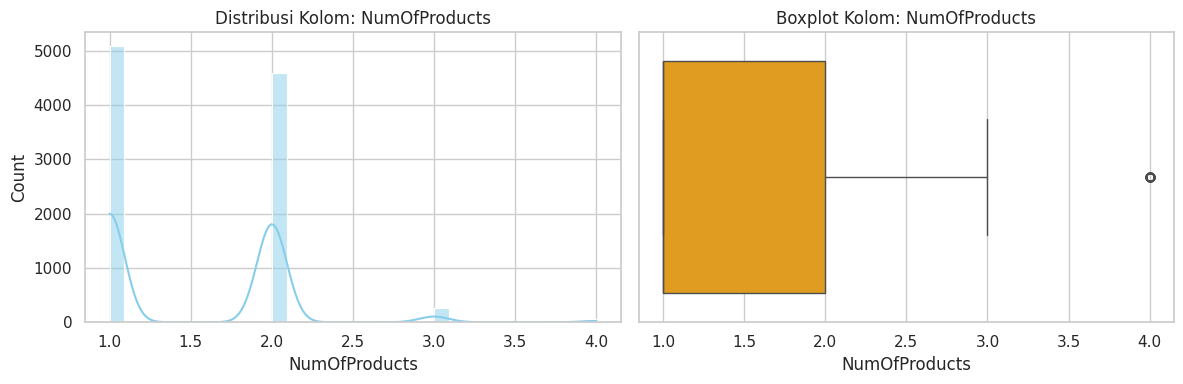

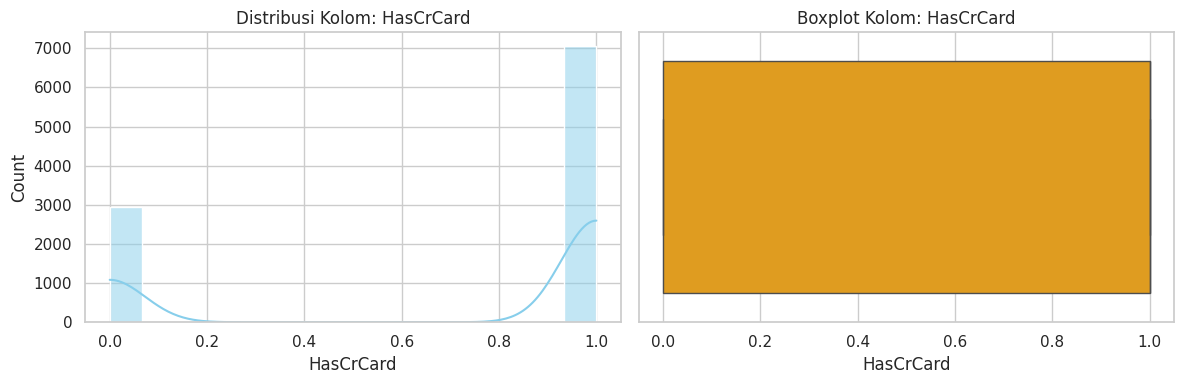

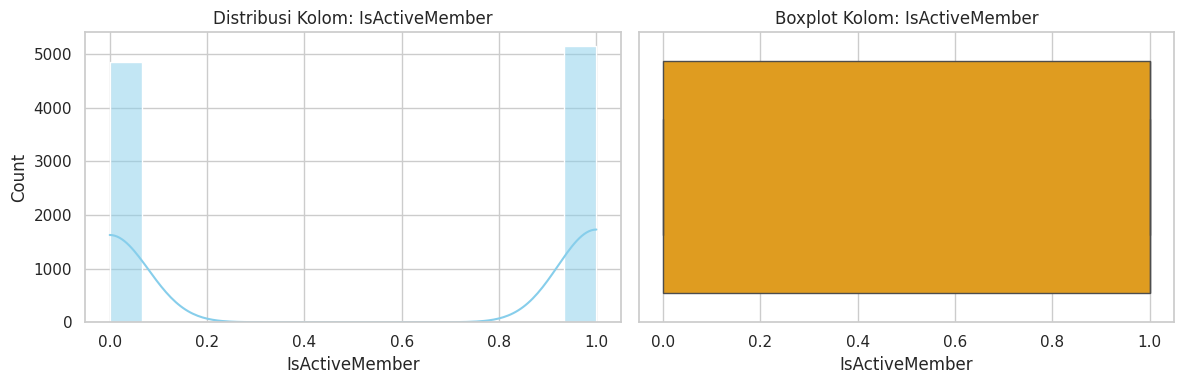

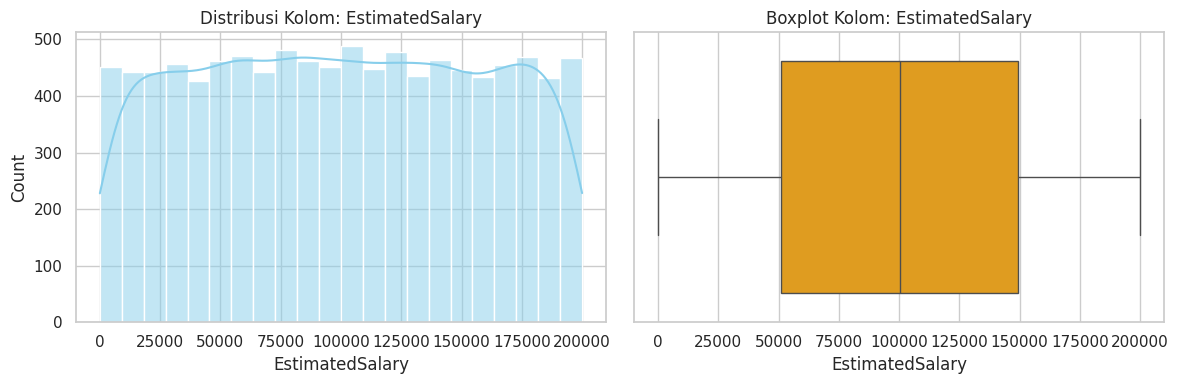

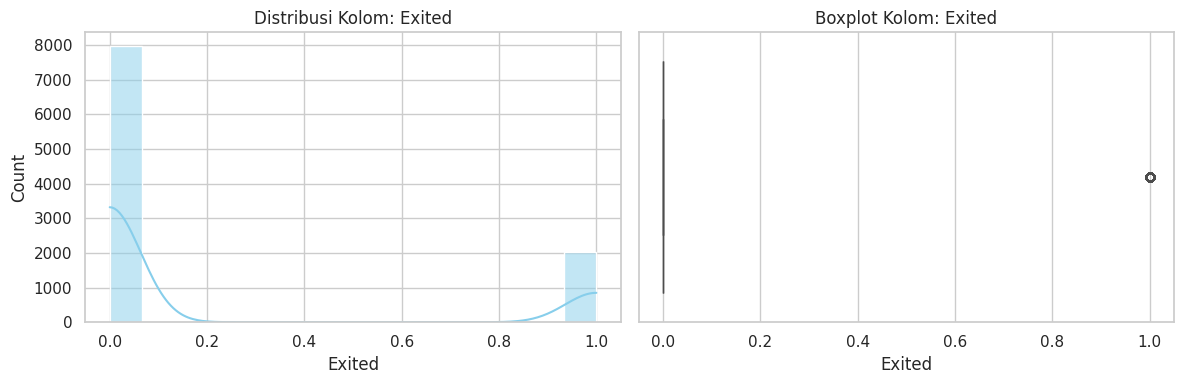

In [ ]:
numerik_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerik_cols:
    plt.figure(figsize=(12, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribusi Kolom: {col}")

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='orange')
    plt.title(f"Boxplot Kolom: {col}")

    plt.tight_layout()
    plt.show()

📊 Analisis Distribusi dan Boxplot Kolom Numerik

1. Kolom: CreditScore
* Distribusi:

  - Distribusi CreditScore terlihat seperti distribusi normal miring ke kiri (left-skewed).

  - Mayoritas skor berkisar antara 600 hingga 700.

  - Ada puncak aneh di bagian atas sekitar 850

* Boxplot:

  - Terdapat beberapa outlier di sisi bawah (skor kredit rendah).

  - Median skor kredit berada di sekitar 650.

  - Rentang interkuartil lebar

2. Kolom: Age
* Distribusi:

  - Skewed ke kanan (right-skewed), dengan mayoritas data berada di rentang usia 30-40 tahun.

* Boxplot:

  - Median usia sekitar 37-38 tahun.

  - Banyak outlier pada kelompok usia di atas 60 tahun, menunjukkan keberadaan pelanggan yang jauh lebih tua dari mayoritas.

  - Penyebaran cukup luas, dari usia sekitar 18 hingga di atas 90.

3. Kolom: Tenure
* Distribusi:

  - Distribusi Tenure (lama menjadi nasabah) bersifat hampir seragam.

  - Setiap nilai dari 0 hingga 10 tahun memiliki jumlah pelanggan yang hampir sama.

* Boxplot:

  - Median tenure sekitar 5 tahun.

  - Tidak ada outlier yang signifikan.

  - Penyebaran merata.

4. Kolom: Balance
* Distribusi:

  - Ada puncak tinggi di sekitar saldo 0, kemungkinan karena banyak pelanggan tidak memiliki saldo.

  - Puncak kedua terlihat di sekitar 120.000.

* Boxplot:

  - Tidak terlihat outlier signifikan.

  - Median saldo berada di bawah 100.000.

  - Penyebaran nilai cukup luas, dari 0 hingga mendekati 250.000.

5. Kolom: NumOfProducts
* Distribusi:

  - Distribusi bersifat diskrit dan dominan di nilai 1 dan 2 produk.

  - Sedikit pelanggan yang memiliki 3 produk, dan sangat sedikit yang memiliki 4 produk.

* Boxplot:

  - Median berada di sekitar 2 produk.

  - Nilai 4 terdeteksi sebagai outlier.

  - Sebagian besar pelanggan memiliki 1-2 produk, menunjukkan distribusi yang tidak merata.

6. Kolom: HasCrCard
* Distribusi:

  - Kolom ini merupakan data biner (0 = tidak memiliki kartu kredit, 1 = memiliki).

  - Mayoritas pelanggan memiliki kartu kredit (nilai 1), sedangkan sebagian kecil tidak memilikinya.

* Boxplot:

  - Tidak menunjukkan outlier.

  - Boxplot menampilkan distribusi penuh dari 0 ke 1.

7. Kolom: EstimatedSalary
* Distribusi:

  - Distribusi terlihat mendekati seragam dari 0 hingga 200.000.

  - Tidak ada puncak (peak) yang menonjol, menunjukkan nilai gaji tersebar merata di seluruh rentang.

* Boxplot:
  - Rentang nilai menyebar luas tanpa outlier yang mencolok.

  - Median berada di sekitar pertengahan (sekitar 100.000).

  - Data cukup simetris dengan persebaran yang merata.

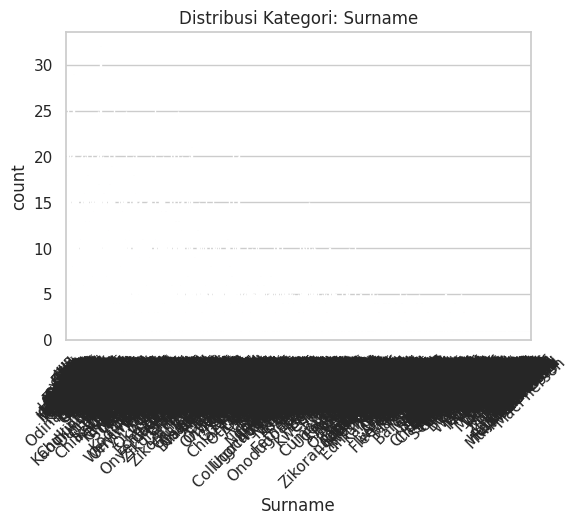

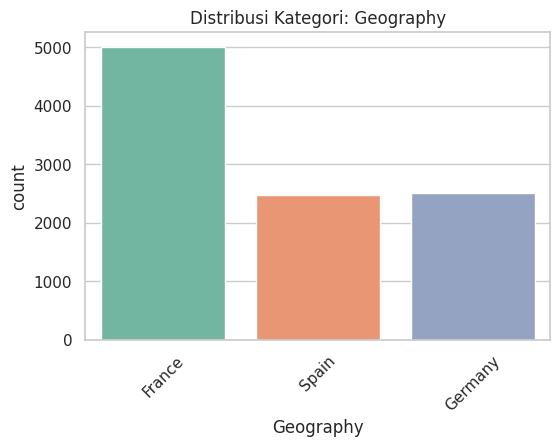

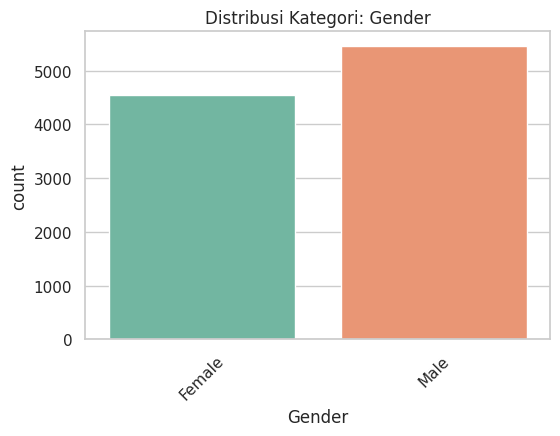

In [ ]:
kategori_cols = df.select_dtypes(include='object').columns

for col in kategori_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f"Distribusi Kategori: {col}")
    plt.xticks(rotation=45)
    plt.show()


📊 Analisis Distribusi dan Boxplot Kolom Kategori

1. Kolom: Geography
* Terdiri dari 3 kategori: France, Spain, dan Germany.

* Distribusi:

  - France mendominasi (~50% data).

  - Spain dan Germany memiliki jumlah yang hampir seimbang dan lebih rendah dari France.

2. Kolom: Gender
* Terdiri dari dua kategori: Female dan Male.

* Distribusi cukup seimbang:

  - Male sedikit lebih banyak daripada Female.

### Multivariate Analysis

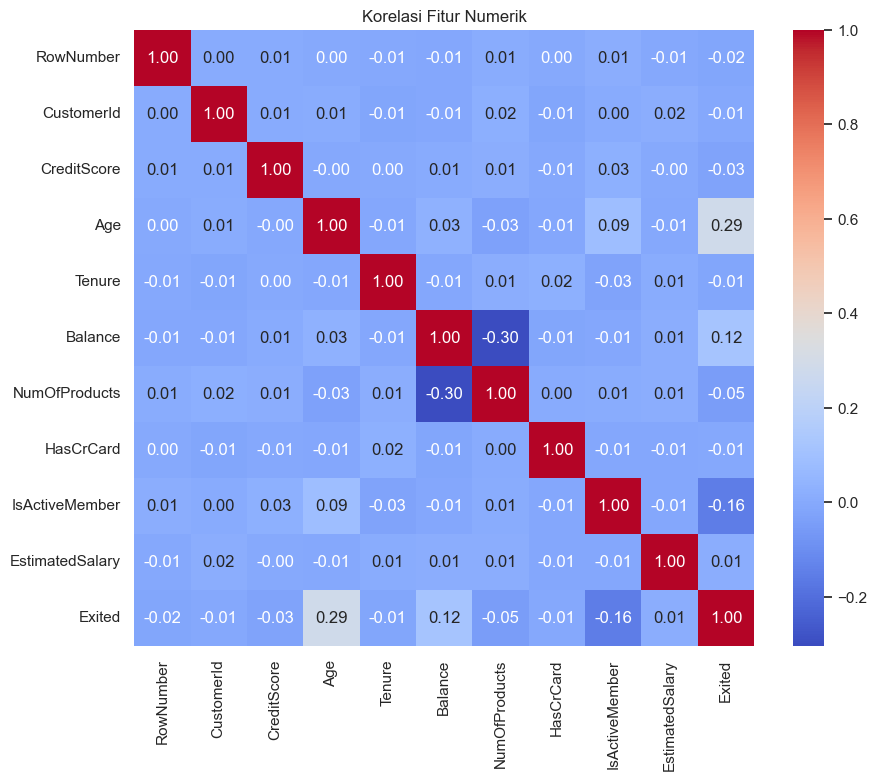

In [ ]:
# Korelasi antar fitur numerik
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])  # ambil kolom numerik
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasi Fitur Numerik")
plt.show()


### 🔥 Heatmap Korelasi Antar Fitur Numerik

Heatmap di atas menggambarkan **hubungan korelasi antar fitur numerik** dalam dataset. Nilai korelasi berkisar antara -1 hingga 1:

- 🔴 **Mendekati +1**: Korelasi positif kuat (fitur naik bersama-sama)
- 🔵 **Mendekati -1**: Korelasi negatif kuat (fitur berlawanan arah)
- ⚪ **Mendekati 0**: Tidak ada korelasi linear yang signifikan

#### 📌 Temuan Penting:

- **`Age` vs `Exited`:** Memiliki korelasi positif moderat sebesar **0.29**, menunjukkan bahwa semakin tua pelanggan, semakin besar kemungkinan mereka untuk keluar dari bank.
- **`IsActiveMember` vs `Exited`:** Korelasi negatif sebesar **-0.16**, mengindikasikan bahwa pelanggan aktif cenderung tetap menjadi nasabah.
- **`Balance` vs `Exited`:** Korelasi positif lemah **(0.12)**, artinya nasabah dengan saldo lebih tinggi sedikit lebih mungkin keluar.
- **`NumOfProducts` vs `Balance`:** Korelasi negatif sebesar **-0.30**, mengindikasikan bahwa pelanggan dengan lebih banyak produk justru cenderung memiliki saldo lebih rendah.
- Kolom seperti `RowNumber`, `CustomerId`, dan `Surname` tidak memiliki korelasi signifikan terhadap `Exited`, dan seringkali dapat dihapus pada tahap pemodelan.

#### 🎯 Kesimpulan:
Beberapa fitur seperti `Age`, `IsActiveMember`, dan `Balance` memberikan sinyal awal bahwa mereka dapat menjadi fitur penting dalam proses prediksi churn.


### Bivariate Analysis
#### 👩‍🦰 Distribusi Churn berdasarkan Gender

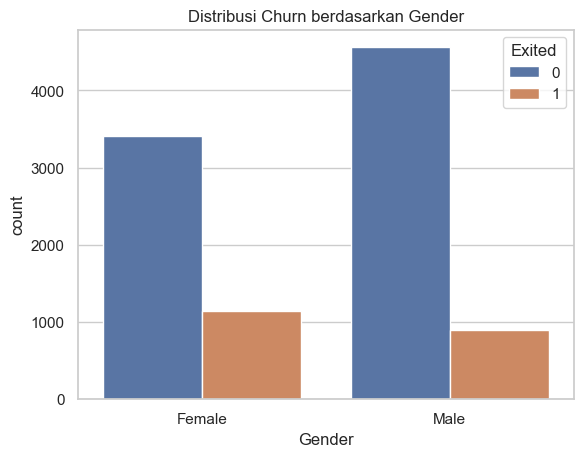

In [ ]:
# Distribusi churn berdasarkan Gender
sns.countplot(data=df, x='Gender', hue='Exited')
plt.title("Distribusi Churn berdasarkan Gender")
plt.show()


#### 📊 Insight yang Didapat:

- **Nasabah Laki-laki (Male)** lebih banyak secara keseluruhan dibandingkan nasabah perempuan.
- Namun, **nasabah perempuan memiliki tingkat churn yang lebih tinggi** dibandingkan laki-laki.

### 🌍 Distribusi Churn berdasarkan Geography

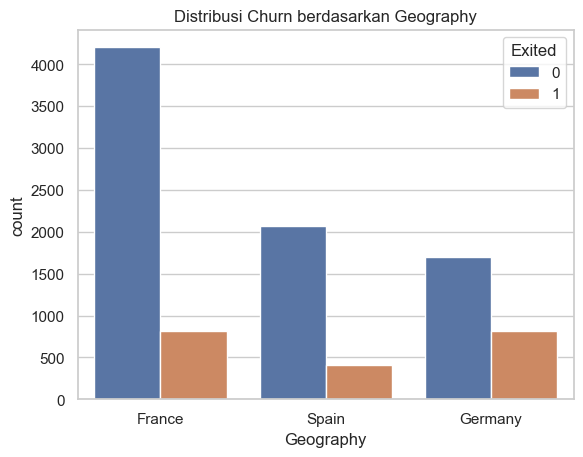

In [ ]:
# Distribusi churn berdasarkan Geography
sns.countplot(data=df, x='Geography', hue='Exited')
plt.title("Distribusi Churn berdasarkan Geography")
plt.show()


#### 📊 Insight yang Didapat:

Plot ini membantu kita memahami pengaruh lokasi geografis:
- Nasabah dari **Germany** dan **France** memiliki tingkat churn yang tinggi dibandingkan Spain.
- Sebaliknya, **nasabah dari Spain** memiliki tingkat churn paling rendah.


## Kesimpulan

- Dataset tidak memiliki missing values dan siap dianalisis lebih lanjut.
- Fitur `Geography`, `Gender`, `Age`, dan `IsActiveMember` tampak memiliki hubungan dengan churn.
- Target sedikit imbalanced, perlu strategi khusus saat pemodelan

Selanjutnya kita bisa melakukan **pembersihan dan encoding data**, lalu masuk ke tahap pemodelan prediktif.

## 4. Data Preprocessing
Mempersiapkan data untuk digunakan dalam model pembelajaran mesin.


### **Feature Engineering**

Feature engineering merupakan proses penting untuk menyiapkan data sebelum digunakan oleh model. Di tahap ini, fitur-fitur (kolom) dalam dataset diolah agar lebih informatif dan mudah diproses oleh algoritma machine learning.

#### **Menghapus Kolom yang Tidak Relevan**

Menghapus kolom-kolom yang tidak memiliki pengaruh signifikan terhadap proses prediksi, seperti ID unik dan nama pelanggan. Hal ini dilakukan untuk menyederhanakan dataset dan menghindari noise pada model.


In [ ]:
# Hapus kolom 'email'
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

#### **Data Transformation**

1. **Label Encoding pada Kolom 'Gender'**  
   `LabelEncoder` dari `sklearn.preprocessing` digunakan untuk mengubah nilai kategorikal pada kolom **'Gender'** menjadi format numerik. Ini berguna agar model pembelajaran mesin dapat memproses data kategorikal yang berupa teks.

2. **One-Hot Encoding pada Kolom 'Geography'**  
   `pd.get_dummies` digunakan untuk mengubah kolom **'Geography'** yang memiliki nilai kategorikal menjadi beberapa kolom biner (0 atau 1). Pilihan `drop_first=True` digunakan untuk menghindari masalah multikolinearitas dengan menghapus satu kolom hasil encoding.


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode Gender
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [ ]:
df.head(10)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True
5,645,1,44,8,113755.78,2,1,0,149756.71,1,False,True
6,822,1,50,7,0.00,2,1,1,10062.80,0,False,False
7,376,0,29,4,115046.74,4,1,0,119346.88,1,True,False
8,501,1,44,4,142051.07,2,0,1,74940.50,0,False,False
9,684,1,27,2,134603.88,1,1,1,71725.73,0,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  bool   
 11  Geography_Spain    10000 non-null  bool   
dtypes: bool(2), float64(2), int64(8)
memory usage: 800.9 KB


#### **Feature Selection (Seleksi Fitur)**
- **X** berisi data fitur yang akan digunakan untuk melatih model.
- **y** berisi data target yang akan diprediksi oleh model.

In [ ]:
X=df.drop("Exited",axis=1)
y=df["Exited"]

#### **Handling Imbalanced Data**
**SMOTE** digunakan untuk menyeimbangkan distribusi kelas dalam dataset, dengan meningkatkan jumlah contoh dari kelas minoritas, yang sangat penting dalam algoritma pembelajaran mesin yang sensitif terhadap ketidakseimbangan kelas.

In [ ]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

#### **Feature Scaling**
**StandardScaler** mengubah fitur numerik menjadi distribusi dengan mean = 0 dan standar deviasi = 1.

In [ ]:
# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_smote)

#### **Data Splitting**
Membagi data menjadi **training set** dan **test set**, sehingga model dapat dilatih dengan data pelatihan.

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_smote, test_size=0.2, random_state=42)

## 5. Memilih Model

Metode Klasifikasi yang Digunakan:
1. **XGBoost (Extreme Gradient Boosting)**
2. **Random Forest Classifier**

### **Mengapa?**
###🔸 **1. XGBoost**  
XGBoost adalah algoritma berbasis ensemble **Gradient Boosting** yang dikenal karena **akurasi tinggi, efisiensi, dan kemampuan menangani data tidak seimbang**.  
**Alasan memilih XGBoost:**
- ⚡ **Kinerja Tinggi**: Mampu menghasilkan prediksi yang sangat akurat, cocok untuk dataset dengan fitur kompleks seperti data perbankan.
- 🧮 **Mampu Menangani Missing Value & Outlier**: Tidak sensitif terhadap data yang tidak sempurna.
- 🎯 **Fokus pada Error yang Sulit**: Melatih model baru untuk memperbaiki kesalahan dari model sebelumnya, sehingga sangat efektif untuk prediksi churn (yang umumnya minoritas).
- 🛠️ **Hyperparameter Tuning Fleksibel**: Memungkinkan penyetelan yang detail untuk mengoptimalkan performa.

---

### 🔸 **2. Random Forest Classifier**
Random Forest adalah metode *bagging* yang membangun banyak pohon keputusan dan menggabungkan hasilnya untuk prediksi akhir.  
**Alasan memilih Random Forest:**
- 🌳 **Stabil dan Handal**: Mengurangi overfitting dengan menggabungkan prediksi dari banyak pohon.
- 🧩 **Menangani Data Campuran**: Cocok untuk data tabular yang memiliki fitur numerik dan kategorikal.
- ⚖️ **Resisten terhadap Data Tidak Seimbang**: Performa tetap baik meskipun target `Exited` mungkin tidak seimbang.
- 📊 **Feature Importance**: Memudahkan interpretasi model melalui nilai pentingnya setiap fitur.

---

## 🧾 Kesimpulan:
Kedua metode ini **sangat cocok** digunakan dalam masalah prediksi customer churn karena:
- Dataset bersifat **tabular dengan kombinasi fitur numerik dan kategorikal**.
- Target `Exited` adalah **masalah klasifikasi biner**, cocok untuk algoritma decision tree-based.
- Kedua model mampu menangani **kompleksitas hubungan antar fitur** dan memiliki **akurasi tinggi** dalam berbagai kasus industri, termasuk perbankan.

## 6. Membangun Model

### **XGBoost**
Melatih model **XGBoost** pada data pelatihan untuk memprediksi target variabel berdasarkan fitur yang telah disiapkan.

In [ ]:
XGB = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
XGB.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

**Evaluasi Model**

In [ ]:
y_pred_xgb = XGB.predict(X_test)
print(classification_report(y_test, y_pred_xgb, target_names=['Stayed', 'Exited']))

              precision    recall  f1-score   support

      Stayed       0.88      0.87      0.87      1633
      Exited       0.86      0.88      0.87      1553

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186



Model memiliki **akurasi 87%**, dengan performa yang cukup seimbang antara **Stayed** dan **Exited**, baik dari segi **precision**, **recall**, maupun **F1-score**.

### **XGBoost with GridSearchCV**

Meningkatkan performa model XGBoost dengan mencari kombinasi hyperparameter terbaik menggunakan teknik grid search dan evaluasi berbasis precision.

In [ ]:
# Hyperparameter tuning for XGBoost
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [8, 10],
    'learning_rate': [0.01, 0.03],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0.1, 0.2]}
xgb = XGBClassifier(random_state=42)
grid_search = GridSearchCV(xgb, param_grid, cv=3, scoring='precision', n_jobs=-1)
grid_search.fit(X_train, y_train)
optimized_xgb = grid_search.best_estimator_

**Evaluasi Model GridSeacrhCV**

In [ ]:
# Evaluasi model terbaik
y_pred_best = optimized_xgb.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=['Stayed', 'Exited']))

              precision    recall  f1-score   support

      Stayed       0.89      0.88      0.88      1633
      Exited       0.87      0.88      0.88      1553

    accuracy                           0.88      3186
   macro avg       0.88      0.88      0.88      3186
weighted avg       0.88      0.88      0.88      3186



Tuning hyperparameter berhasil meningkatkan performa model XGBoost dengan akurasi dari 87% menjadi 88%.

**Melihat Akurasi**

In [ ]:
from sklearn.metrics import accuracy_score
print("Akurasi pada data uji: ", accuracy_score(y_test, y_pred_best))

Akurasi pada data uji:  0.8801004394224733


Model menghasilkan akurasi sebesar 88% pada data uji, yang menunjukkan bahwa model dapat memprediksi dengan benar sekitar 88% dari total data uji.

**Confusion Matrix**

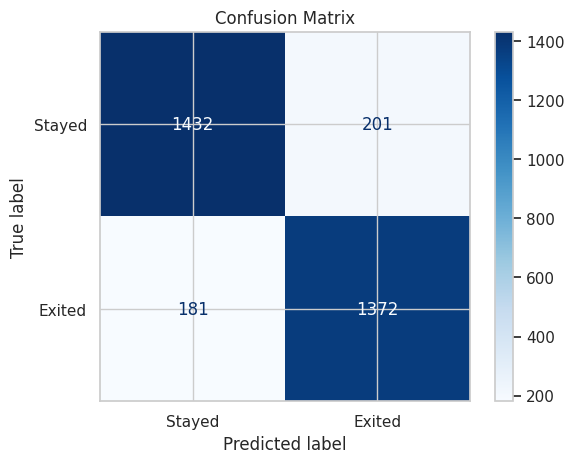

In [ ]:
# Hitung confusion matrix (pakai label berupa angka)
cm = confusion_matrix(y_test, y_pred_best, labels=[0, 1])

# Visualisasikan confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Exited'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Berdasarkan confusion matrix, model berhasil memprediksi **1.432 data Stayed** dan **1.372 data Exited** dengan benar. Ini menandakan bahwa model memiliki akurasi yang tinggi dan performa yang seimbang dalam mengklasifikasikan kedua kelas.


### **RandomForestClassifier**
Melatih model **Random Forest** pada data pelatihan untuk memprediksi target variabel berdasarkan fitur yang telah disiapkan, dengan penyesuaian bobot kelas untuk menangani data yang tidak seimbang.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(class_weight='balanced', n_estimators=100)
clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

**Evaluasi Model**

In [ ]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Exited']))

              precision    recall  f1-score   support

      Stayed       0.88      0.87      0.88      1633
      Exited       0.87      0.87      0.87      1553

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186



Model Random Forest menghasilkan akurasi sebesar **87%** pada data uji, dengan performa yang cukup seimbang antara kelas **Stayed** dan **Exited**.
Rata-rata **macro avg** dan **weighted avg** juga bernilai 0.87, menunjukkan konsistensi performa antar kelas.

### **RandomForestClassifier with GridSearchCV**
Melakukan **tuning hyperparameter** untuk model Random Forest.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid untuk Random Forest
param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Inisialisasi model
rf = RandomForestClassifier(random_state=42)

# GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf,
                              param_grid=param_grid_rf,
                              cv=3,
                              scoring='precision',
                              n_jobs=-1,
                              verbose=1)

# Fit ke training data
grid_search_rf.fit(X_train, y_train)

# Ambil model terbaik
optimized_rf = grid_search_rf.best_estimator_

# Tampilkan hasil terbaik
print("Best Parameters for Random Forest:", grid_search_rf.best_params_)
print("Best Precision Score:", grid_search_rf.best_score_)

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best Parameters for Random Forest: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best Precision Score: 0.8719437848575234


**Evaluasi Model GridSeacrhCV**

In [ ]:
# Evaluasi model terbaik
y_pred_rf = optimized_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Exited']))

              precision    recall  f1-score   support

      Stayed       0.88      0.88      0.88      1633
      Exited       0.87      0.87      0.87      1553

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186



Model menunjukkan performa yang cukup baik dengan precision, recall, dan f1-score sekitar 0.87 - 0.88 untuk kedua kelas "Stayed" dan "Exited", dengan accuracy keseluruhan sebesar 87%.

**Melihat akurasi**

In [ ]:
from sklearn.metrics import accuracy_score
print("Akurasi pada data uji: ", accuracy_score(y_test, y_pred_rf))

Akurasi pada data uji:  0.8731952291274325


Model menghasilkan akurasi sebesar 87% pada data uji, yang menunjukkan bahwa model dapat memprediksi dengan benar sekitar 87% dari total data uji.

**Confusion Matrix**

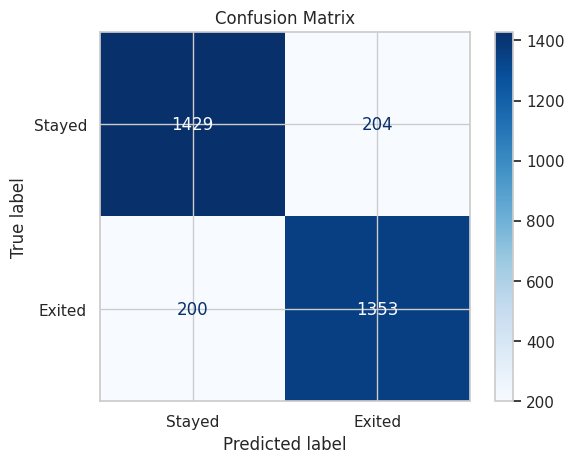

In [ ]:
# Hitung confusion matrix (pakai label berupa angka)
cm = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])

# Visualisasikan confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Exited'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Model berhasil mengklasifikasikan 1.429 data *Stayed* dan 1.353 data *Exited* dengan benar. Sementara itu, terdapat kesalahan klasifikasi sebanyak 204 *Stayed* yang diprediksi sebagai *Exited*, dan 200 *Exited* yang diprediksi sebagai *Stayed*. Secara umum, model menunjukkan performa yang baik dengan jumlah prediksi benar yang jauh lebih tinggi dibandingkan dengan kesalahan klasifikasi.


### 7. Analisis Hasil XGBoost dan RandomForestClassifier

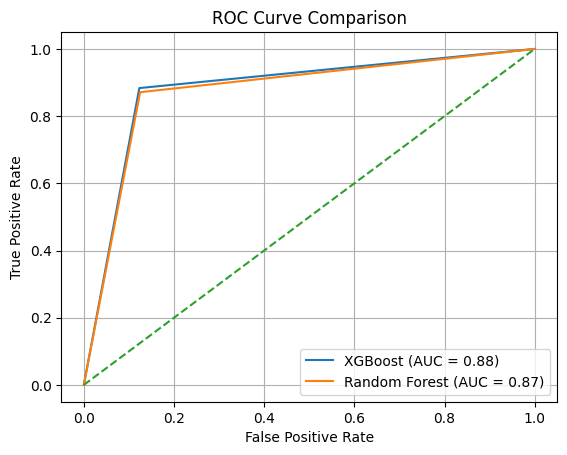

In [ ]:
from sklearn.metrics import roc_curve, RocCurveDisplay, auc

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_best)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)

plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()
plt.show()

Grafik ROC Curve di atas menunjukkan perbandingan performa model XGBoost dan Random Forest dalam klasifikasi biner. Kurva ROC menggambarkan trade-off antara *True Positive Rate* (TPR) dan *False Positive Rate* (FPR). Semakin mendekati sudut kiri atas, semakin baik performa model.

Model XGBoost memiliki nilai AUC (Area Under Curve) sebesar 0.88, sedikit lebih tinggi dibandingkan Random Forest dengan AUC sebesar 0.87. Ini menunjukkan bahwa XGBoost sedikit lebih unggul dalam membedakan antara kelas positif dan negatif. Garis putus-putus hijau menunjukkan baseline (AUC = 0.5), yang berarti model acak tanpa kemampuan klasifikasi. Kedua model jauh lebih baik dari baseline, namun XGBoost menunjukkan performa yang sedikit lebih optimal dalam hal klasifikasi.

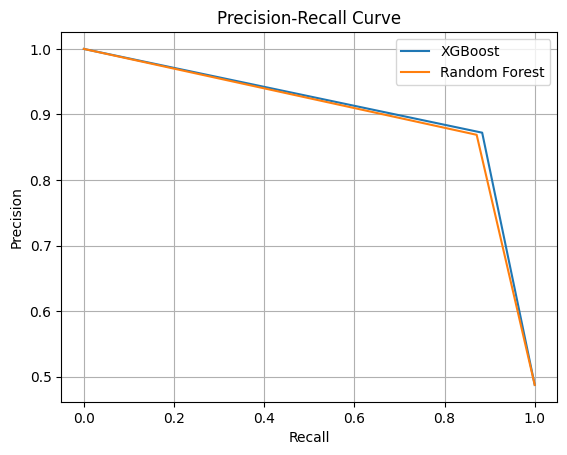

In [ ]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_best)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_rf)

plt.plot(recall_xgb, precision_xgb, label='XGBoost')
plt.plot(recall_rf, precision_rf, label='Random Forest')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()


Secara umum, kurva XGBoost dan Random Forest terlihat sangat mirip, menunjukkan bahwa kedua model memiliki performa yang sebanding dalam hal *precision* (ketepatan) dan *recall* (cakupan). Namun, XGBoost sedikit lebih unggul pada sebagian besar titik, terutama pada nilai *recall* yang tinggi, di mana precision-nya tetap lebih stabil dibandingkan Random Forest. Hal ini menunjukkan bahwa XGBoost cenderung memberikan prediksi positif yang lebih akurat ketika mencoba mencakup sebanyak mungkin kasus positif (recall tinggi).


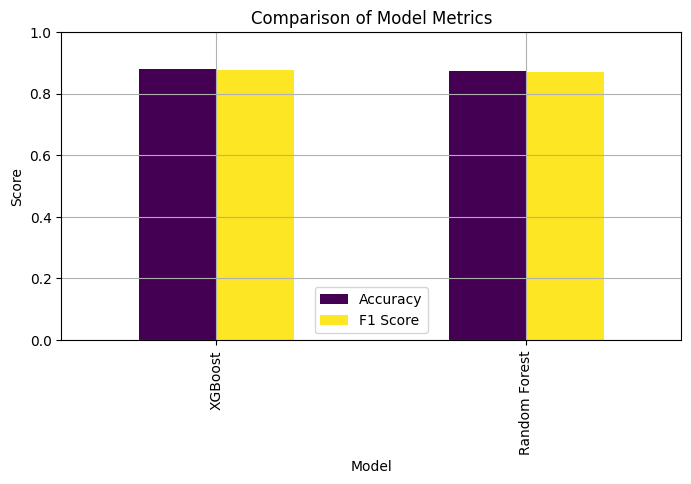

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

metrics = {
    'Model': ['XGBoost', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_best), accuracy_score(y_test, y_pred_rf)],
    'F1 Score': [f1_score(y_test, y_pred_best), f1_score(y_test, y_pred_rf)]
}

df_metrics = pd.DataFrame(metrics)
df_metrics.set_index('Model').plot(kind='bar', figsize=(8, 4), colormap='viridis')
plt.title("Comparison of Model Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


Grafik di atas membandingkan dua metrik utama, yaitu *Accuracy* dan *F1 Score*, dari dua model klasifikasi: XGBoost dan Random Forest. Kedua model menunjukkan performa yang sangat mirip, dengan XGBoost sedikit unggul dalam kedua metrik.

Nilai *accuracy* dan *F1 score* untuk XGBoost dan Random Forest berada di atas 0.85, menandakan bahwa kedua model memiliki kemampuan klasifikasi yang tinggi. Kelebihan F1 Score adalah mampu menangani ketidakseimbangan data dengan baik karena menggabungkan precision dan recall. Dengan demikian, meskipun perbedaannya kecil, XGBoost menunjukkan performa yang sedikit lebih konsisten dan seimbang dibandingkan Random Forest.